<a href="https://colab.research.google.com/github/renisha04/Machine-Learning-Lab/blob/main/ML_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape, LeakyReLU, BatchNormalization, Conv2DTranspose, Conv2D, Dropout
from tensorflow.keras.optimizers import Adam

In [66]:

df = pd.read_csv("mnist_test.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Separate label and pixel values
X = df.iloc[:, 1:].values.astype("float32")

# Check number of pixels
if X.shape[1] != 784:
    raise ValueError(
        "Dataset must contain 784 pixel columns. "
        "Please check your MNIST CSV file."
    )

# Normalize pixel values: 0-255 -> -1 to 1
X = (X - 127.5) / 127.5

# Reshape images
X = X.reshape(-1, 28, 28, 1)

print("Images normalized successfully!")
print("Image shape:", X.shape)

Dataset loaded successfully!
Dataset shape: (10000, 785)
Images normalized successfully!
Image shape: (10000, 28, 28, 1)


In [67]:
def build_generator():

    model = Sequential(name="Generator")

    model.add(Dense(128, input_shape=(100,)))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(784, activation="tanh"))

    model.add(Reshape((28, 28, 1)))

    return model

In [68]:
def build_discriminator():

    model = Sequential(name="Discriminator")

    model.add(
        Flatten(input_shape=(28, 28, 1))
    )

    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(64))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(
            learning_rate=0.0002,
            beta_1=0.5
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [69]:
generator = build_generator()
discriminator = build_discriminator()

print("\nGenerator Summary:")
generator.summary()

print("\nDiscriminator Summary:")
discriminator.summary()



Generator Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
discriminator.trainable = False

gan = Sequential(name="GAN")

gan.add(generator)
gan.add(discriminator)

gan.compile(
    optimizer=Adam(
        learning_rate=0.0002,
        beta_1=0.5
    ),
    loss="binary_crossentropy"
)

print("\nGAN created successfully!")


GAN created successfully!


In [71]:
epochs = 200
batch_size = 184

for epoch in range(epochs):

    # -----------------------------
    # Train Discriminator
    # -----------------------------

    # Select real images
    index = np.random.randint(
        0,
        X.shape[0],
        batch_size
    )

    real_images = X[index]

    # Generate random noise
    noise = np.random.normal(
        0,
        1,
        (batch_size, 100)
    )

    # Generate fake images
    fake_images = generator.predict(
        noise,
        verbose=0
    )

    # Real = 1, Fake = 0
    real_labels = np.ones(
        (batch_size, 1)
    )

    fake_labels = np.zeros(
        (batch_size, 1)
    )

    # Enable discriminator training
    discriminator.trainable = True

    d_loss_real = discriminator.train_on_batch(
        real_images,
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_images,
        fake_labels
    )

    d_loss = (
        np.array(d_loss_real) +
        np.array(d_loss_fake)
    ) / 2

    # -----------------------------
    # Train Generator
    # -----------------------------

    discriminator.trainable = False

    noise = np.random.normal(
        0,
        1,
        (batch_size, 100)
    )

    # Generator wants fake images
    # to be classified as real
    valid_labels = np.ones(
        (batch_size, 1)
    )

    g_loss = gan.train_on_batch(
        noise,
        valid_labels
    )

    print(
        "Epoch {}/{} | "
        "Discriminator Loss: {:.4f} | "
        "Generator Loss: {:.4f}".format(
            epoch + 1,
            epochs,
            float(d_loss[0]),
            float(g_loss)
        )
    )

Epoch 1/200 | Discriminator Loss: 1.3568 | Generator Loss: 0.7496
Epoch 2/200 | Discriminator Loss: 1.0403 | Generator Loss: 0.7139
Epoch 3/200 | Discriminator Loss: 0.9074 | Generator Loss: 0.6809
Epoch 4/200 | Discriminator Loss: 0.8271 | Generator Loss: 0.6551
Epoch 5/200 | Discriminator Loss: 0.7749 | Generator Loss: 0.6308
Epoch 6/200 | Discriminator Loss: 0.7383 | Generator Loss: 0.6093
Epoch 7/200 | Discriminator Loss: 0.7135 | Generator Loss: 0.5882
Epoch 8/200 | Discriminator Loss: 0.6965 | Generator Loss: 0.5706
Epoch 9/200 | Discriminator Loss: 0.6844 | Generator Loss: 0.5544
Epoch 10/200 | Discriminator Loss: 0.6761 | Generator Loss: 0.5406
Epoch 11/200 | Discriminator Loss: 0.6702 | Generator Loss: 0.5281
Epoch 12/200 | Discriminator Loss: 0.6656 | Generator Loss: 0.5167
Epoch 13/200 | Discriminator Loss: 0.6622 | Generator Loss: 0.5070
Epoch 14/200 | Discriminator Loss: 0.6598 | Generator Loss: 0.4985
Epoch 15/200 | Discriminator Loss: 0.6582 | Generator Loss: 0.4912
Epoc

In [72]:
noise = np.random.normal(
    0,
    1,
    (10, 100)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

# Convert -1 to 1 back to 0 to 1
generated_images = (
    generated_images + 1
) / 2


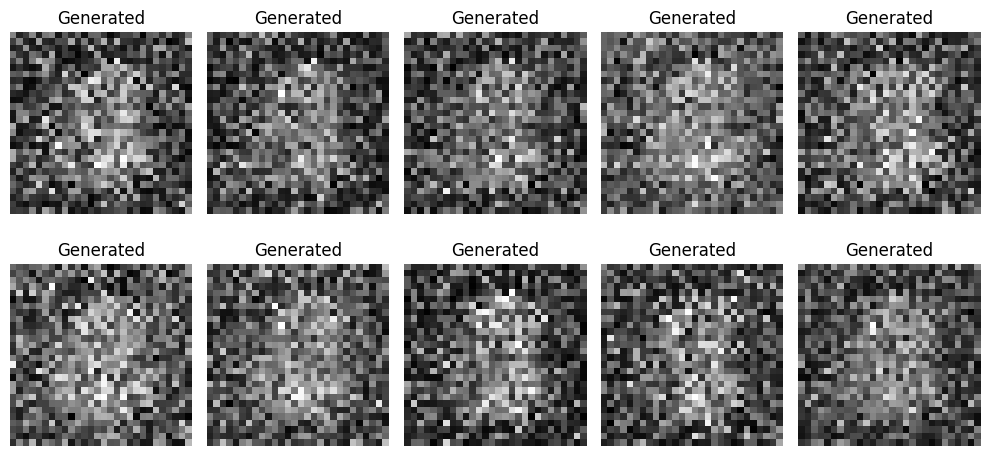

In [73]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        generated_images[i].reshape(28, 28),
        cmap="gray"
    )

    plt.axis("off")
    plt.title("Generated")

plt.tight_layout()
plt.show()

In [74]:
print("\n----------------------------------")
print("GAN TRAINING COMPLETED")
print("----------------------------------")
print("Synthetic images generated: 10")
print("Image size: 28 x 28")
print("Dataset: MNIST")


----------------------------------
GAN TRAINING COMPLETED
----------------------------------
Synthetic images generated: 10
Image size: 28 x 28
Dataset: MNIST
